In [1]:
import pandas as pd
import xarray as xr
import numpy as np
from importlib import reload

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors     as mpcolors
import cartopy.crs as ccrs

import mod_plotting as mod_plot
import mod_regression as mod_reg
import figs_pcm


import figs_datadistributions as figs_dd

In [ ]:
# folder = '../working-vars/regression/trainval-splits/'

# trainDF = pd.read_csv(folder + 'trainDF_allplat_floatparam_pHbias5_pK1_pc8_gmm8_excludeClass3_acc20260126.csv', index_col=0)
# valDF = pd.read_csv(folder + 'valDF_allplat_floatparam_pHbias5_pK1_pc8_gmm8_excludeClass3_acc20260126.csv', index_col=0)

In [ ]:
folder = '../working-vars/regression/trainval-splits/'

# trainDF = pd.read_csv(folder + 'trainDF_allplat_pc8_gmm6_excludeClasses4_pHbias5_pK1_acc20260122.csv', index_col=0)
# valDF = pd.read_csv(folder + 'valDF_allplat_pc8_gmm6_excludeClasses4_pHbias5_pK1_acc20260122.csv', index_col=0)

trainDF = pd.read_csv(folder +  'trainDF_allplat_floatparam_pHbias5_pK1_pc8_gmm7_excludeClass4_acc20260205.csv', index_col=0)
valDF = pd.read_csv(folder +  'valDF_allplat_floatparam_pHbias5_pK1_pc8_gmm7_excludeClass4_acc20260205.csv', index_col=0)


allDF = pd.concat([trainDF, valDF], axis=0)
allClasses = {k:df for k,df in allDF.groupby('cluster')}
trainClasses = {k:df for k,df in trainDF.groupby('cluster')}
valClasses = {k:df for k,df in valDF.groupby('cluster')}

In [22]:
allDF = pd.concat([trainDF, valDF], axis=0)
allClasses = {k:df for k,df in allDF.groupby('cluster')}
trainClasses = {k:df for k,df in trainDF.groupby('cluster')}
valClasses = {k:df for k,df in valDF.groupby('cluster')}

mod_reg.get_trainval_counts(trainClasses, valClasses, n_gmm=6)

,train,validation,train_float,train_ship,val_float,val_ship,train_pc_float,val_pc_float,TOTAL_FLOAT,TOTAL_SHIP,TOTAL_OBS
cluster,,,,,,,,,,,
1,2161,218,573,1588,153,65,26.515502,70.183486,726,1653,2379
2,2648,545,1981,667,365,180,74.811178,66.972477,2346,847,3193
3,1496,447,1266,230,336,111,84.625668,75.167785,1602,341,1943
4,464,73,308,156,35,38,66.379310,47.945205,343,194,537
5,1977,687,1527,450,618,69,77.238240,89.956332,2145,519,2664
6,1569,503,511,1058,222,281,32.568515,44.135189,733,1339,2072


<GeoAxes: title={'center': 'Class 6'}>

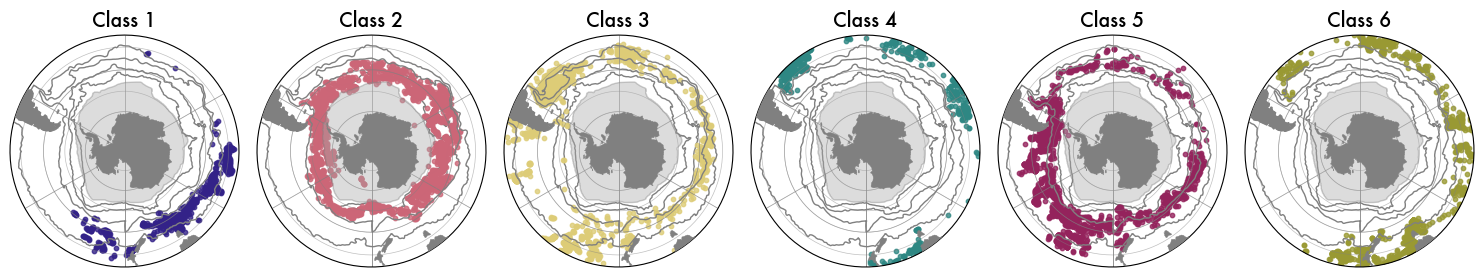

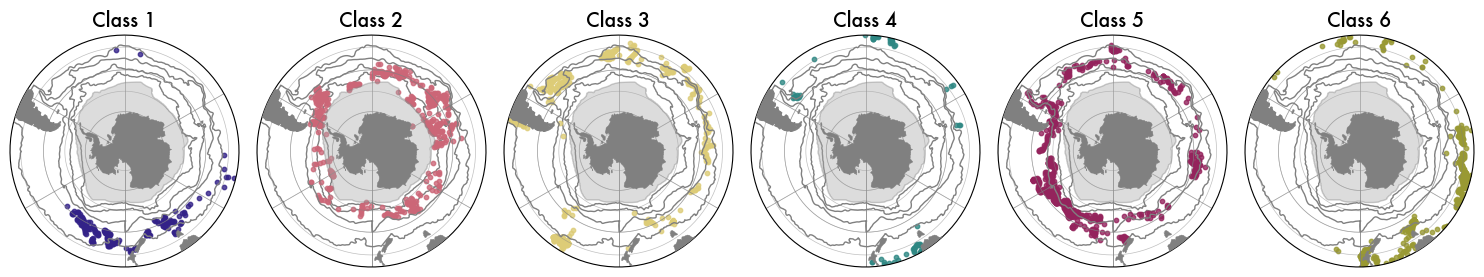

In [34]:


import figs_pcm


figs_pcm.sopolar_classes_paneled(trainClasses, numpanels=[1,6],dotsize=10)
figs_pcm.sopolar_classes_paneled(valClasses, numpanels=[1,6],dotsize=10)


In [ ]:

# traindict = {'combined': trainDF,
#              'float' : trainDF[~trainDF.wmoid.isna()],
#              'ship': trainDF[~trainDF.cruiseid.isna()]}
# valdict = {'combined': valDF,
#             'float' : valDF[~valDF.wmoid.isna()],
#             'ship': valDF[~valDF.cruiseid.isna()]}

# combdict = {'train_comb' : trainDF,
#             'val_comb' : valDF}
# floatdict = {'train_float' : trainDF[~trainDF.wmoid.isna()],
#              'val_float' : valDF[~valDF.wmoid.isna()]}
# shipdict = {'train_ship' : trainDF[~trainDF.cruiseid.isna()],
#             'val_ship' : valDF[~valDF.cruiseid.isna()]}

# train_classes = {k:v for k, v in trainDF.groupby('cluster')}
# val_classes = {k:v for k, v in valDF.groupby('cluster')}



In [25]:
trainDF.cluster.unique()

array([1, 2, 3, 4, 5, 6])

In [24]:
def dict_split_byClass(inputDF, restrict_platform = None):
    if restrict_platform == 'float':
        inputDF = inputDF[~inputDF.wmoid.isna()]
    elif restrict_platform == 'ship':
        inputDF = inputDF[~inputDF.cruiseid.isna()]

    # inputDF = mod_reg.separate_platforms[0]
    
    return {k:v for k, v in inputDF.groupby('cluster')}

def dict_split_byPlatform(inputDF, df_tag, restrict_platform = None, include_combined = True):
    if restrict_platform == 'float':
        inputDF = inputDF[~inputDF.wmoid.isna()]
    elif restrict_platform == 'ship':
        inputDF = inputDF[~inputDF.cruiseid.isna()]

    result = {}
    result[df_tag + '_float'] = inputDF[~inputDF.wmoid.isna()]
    result[df_tag + '_ship'] = inputDF[~inputDF.cruiseid.isna()]
    if include_combined: result[df_tag + '_comb'] = inputDF
    
    return result

def dict_split_trainval(trainDF, valDF, restrict_platform = ''):
    if restrict_platform == 'float':
        trainDF = trainDF[~trainDF.wmoid.isna()]
        valDF = valDF[~valDF.wmoid.isna()]
        restrict_platform = '_float'
    elif restrict_platform == 'ship':
        trainDF = trainDF[~trainDF.cruiseid.isna()]
        valDF = valDF[~valDF.cruiseid.isna()]
        restrict_platform = '_ship'

    result = {} ; 
    result['train' + restrict_platform] = trainDF
    result['val' + restrict_platform] = valDF
    return result


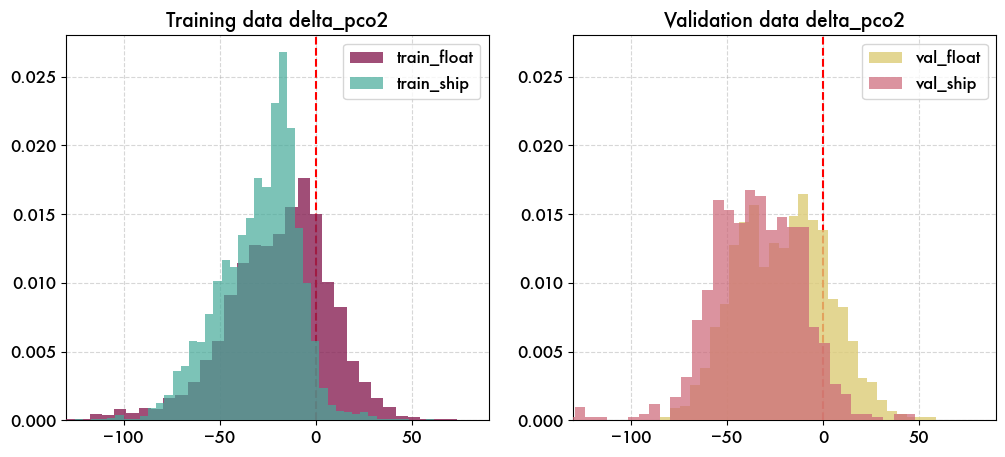

In [26]:
reload(figs_dd)

plotvar = 'delta_pco2'
sns.set_palette('Set2')
fig, axs = plt.subplots(1,2, figsize=(12,5), sharex=True)

for ax in axs[:1]:
    figs_dd.overlay_histograms_singleVar(dict_split_byPlatform(trainDF, "train", include_combined=False), plotvar, ax=ax, nbins=80)
    ax.set_title('Training data ' + plotvar)

for ax in axs[1:2]:
    figs_dd.overlay_histograms_singleVar(dict_split_byPlatform(valDF, "val", include_combined=False), plotvar, ax=ax, nbins=40)
    ax.set_title('Validation data ' + plotvar)

for ax in axs:
    ax.set_xlim([-130,90])
    ax.vlines(x=0, ymin=0, ymax=0.028, colors='r', linestyles='dashed')
    ax.set_ylim([0,0.028])

# ax.set_title('Training vs. Validation Data Distribution for ΔpCO2');

(array([ 118.,  164.,  254.,  331.,  386.,  541.,  694.,  682.,  922.,
        1084., 1129., 1131.,  863.,  712.,  419.,  275.,  272.,  134.,
         132.,   72.]),
 array([2.2645476 , 2.47705224, 2.68955688, 2.90206152, 3.11456616,
        3.3270708 , 3.53957544, 3.75208007, 3.96458471, 4.17708935,
        4.38959399, 4.60209863, 4.81460327, 5.02710791, 5.23961255,
        5.45211719, 5.66462182, 5.87712646, 6.0896311 , 6.30213574,
        6.51464038]),
 <BarContainer object of 20 artists>)

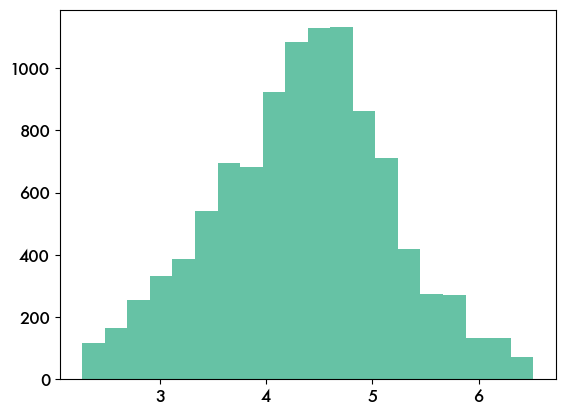

In [35]:
foo = np.log(trainDF.mld)
plt.hist(foo, bins=20)

Distributions between training and validation data


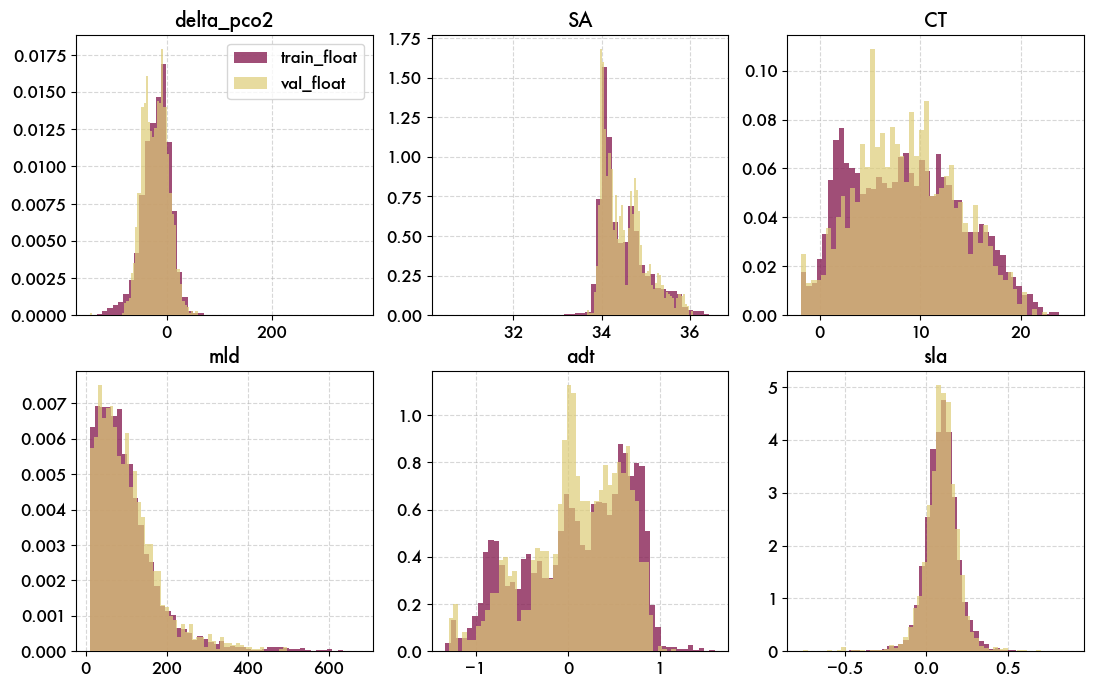

In [29]:
reload(figs_dd)
fig, axs = plt.subplots(2,3, figsize=(13,8))
axs = axs.flatten()

print('Distributions between training and validation data')

# choose_type = 'ship'
choose_type = 'float'
# choose_type = ''

# sns.set_palette('Dark2')
vars_to_plot = ['delta_pco2', 'SA', 'CT', 'mld', 'adt', 'sla']
for ind, val in enumerate(vars_to_plot):
    if ind == 0:
        figs_dd.overlay_histograms_singleVar(dict_split_trainval(trainDF, valDF, choose_type), val, nbins=50, alpha=0.8, ax=axs[ind], showLegend=True)
    else:
        figs_dd.overlay_histograms_singleVar(dict_split_trainval(trainDF, valDF, choose_type), val, nbins=50, alpha=0.8, ax=axs[ind], showLegend=False)
    axs[ind].set_title(val)



In [122]:
train_data_dict[5]

,profid,wmoid,prof_datetag,cluster,datetime,latitude,longitude,linear_time,ydcos,ydsin,...,sampleid,cruiseid,nearest_profid,atm_pres_hPa,fco2rec,class1_prob,class2_prob,class3_prob,class4_prob,class5_prob
463,5904186_id002,5904186.0,5904186_20140419,5,2014-04-19 00:33:59.999999,-52.838,210.006,108.023611,-0.283529,0.958964,...,NaN,NaN,NaN,NaN,NaN,5.909668e-05,3.330870e-36,0.001513,1.214365e-07,0.998428
464,5904186_id003,5904186.0,5904186_20140424,5,2014-04-24 07:41:00.000001,-53.441,210.079,113.320139,-0.369606,0.929189,...,NaN,NaN,NaN,NaN,NaN,8.309411e-05,5.957735e-35,0.005842,4.859343e-07,0.994075
465,5904186_id004,5904186.0,5904186_20140429,5,2014-04-29 14:43:00.000000,-53.472,211.418,118.613194,-0.452564,0.891732,...,NaN,NaN,NaN,NaN,NaN,6.485218e-05,5.111608e-35,0.001102,9.649582e-08,0.998833
466,5904186_id005,5904186.0,5904186_20140505,5,2014-05-05 01:30:00.000000,-52.901,211.919,124.062500,-0.534046,0.845455,...,NaN,NaN,NaN,NaN,NaN,3.498120e-04,2.472713e-29,0.060141,1.639337e-06,0.939508
467,NaN,5904186.0,5904186_20140510,5,2014-05-10 07:54:00.000005,-52.794,211.804,129.329167,-0.608349,0.793670,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10931,5906562_id015,5906562.0,5906562_20230612,5,2023-06-12 04:21:59.999998,-59.273,287.959,3449.181944,-0.937309,0.348500,...,NaN,NaN,NaN,NaN,NaN,8.953900e-08,4.319589e-04,0.001104,5.603808e-10,0.998463
10932,5906562_id016,5906562.0,5906562_20230622,5,2023-06-22 11:14:00.000004,-58.351,290.682,3459.468056,-0.984018,0.178070,...,NaN,NaN,NaN,NaN,NaN,5.827244e-09,2.444313e-04,0.008515,1.639674e-09,0.991240
10933,5906562_id017,5906562.0,5906562_20230702,5,2023-07-02 18:45:00.000000,-59.176,293.565,3469.781250,-0.999999,0.001613,...,NaN,NaN,NaN,NaN,NaN,1.531779e-06,2.766217e-02,0.018327,2.601104e-08,0.954009
10934,5906562_id018,5906562.0,5906562_20230713,5,2023-07-13 01:44:59.999997,-57.093,295.478,3480.072917,-0.984652,-0.174530,...,NaN,NaN,NaN,NaN,NaN,4.160851e-08,1.707406e-07,0.000619,3.237107e-10,0.999381


Distributions between float and ship data, split by class


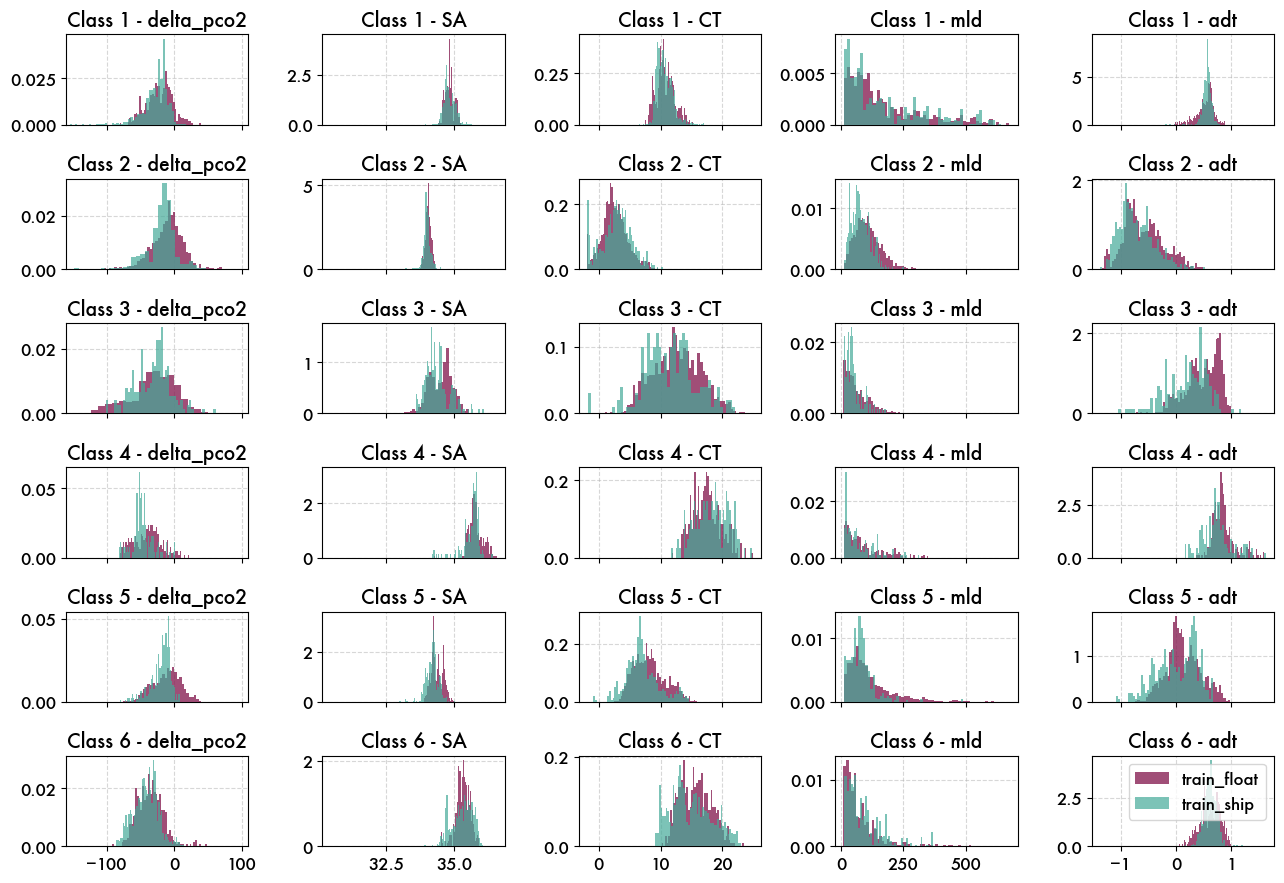

In [32]:
reload(figs_dd)
print('Distributions between float and ship data, split by class')

fig, axs = plt.subplots(6,5, figsize=(13,9), layout='tight', sharex='col')

n_clusters = trainDF.cluster.unique()
vars_to_plot = ['delta_pco2', 'SA', 'CT', 'mld', 'adt']
classes_dict = dict_split_byClass(trainDF)

for nclass in n_clusters:
    plot_data = dict_split_byPlatform(classes_dict[nclass], 'train', include_combined=False)

    for ind, plotvar in enumerate(vars_to_plot):
        ax = axs[nclass-1, ind]

        figs_dd.overlay_histograms_singleVar(plot_data, plotvar, nbins=50, alpha=0.8, ax=ax, showLegend=False)
        ax.set_title(f'Class {nclass} - ' + plotvar)
ax.legend()

for ax in axs[:,0]:
    ax.set_xlim([-160,110])
    # ax.vlines(x=0, ymin=0, ymax=0.028, colors='r', linestyles='dashed')

Distributions between train and val data, split by class


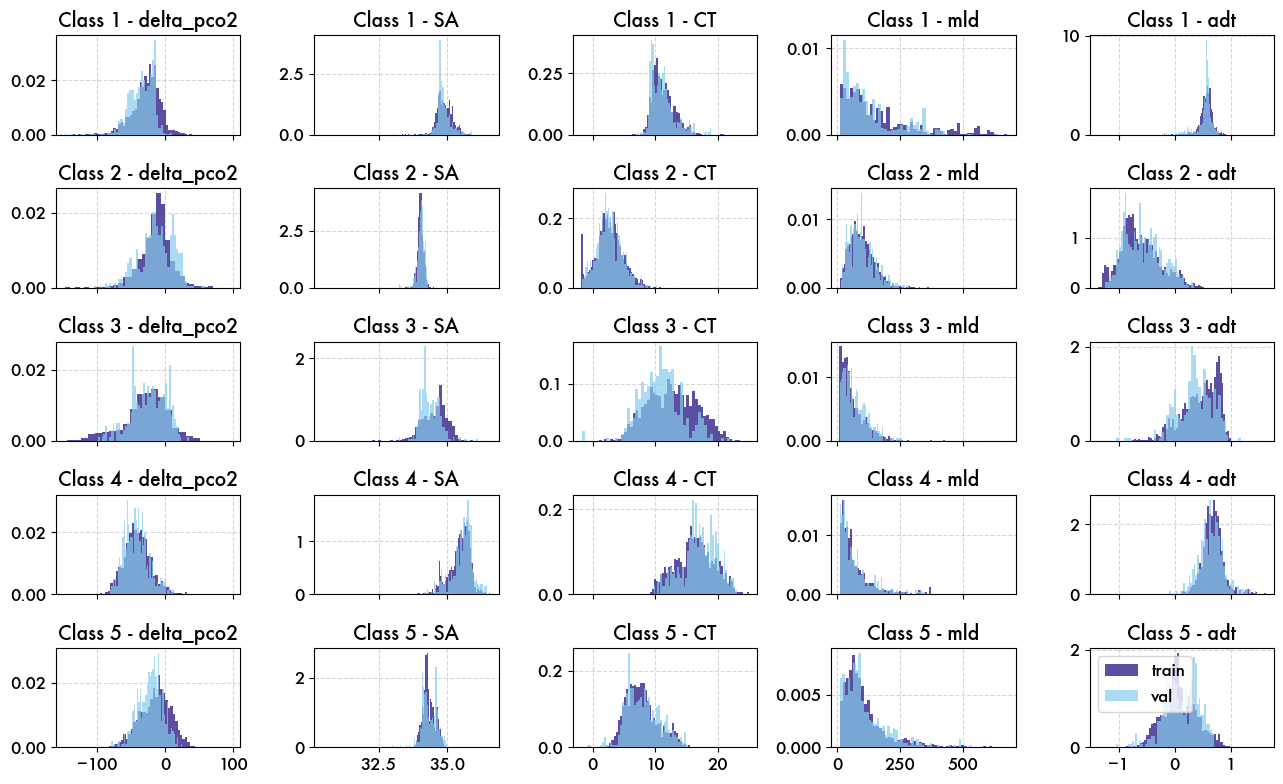

In [13]:
reload(figs_dd)
print('Distributions between train and val data, split by class')

fig, axs = plt.subplots(5,5, figsize=(13,8), layout='tight', sharex='col')

n_clusters = trainDF.cluster.unique()
vars_to_plot = ['delta_pco2', 'SA', 'CT', 'mld', 'adt']
train_classes_dict = dict_split_byClass(trainDF)
val_classes_dict = dict_split_byClass(valDF)

for nclass in n_clusters:
    plot_data = dict_split_trainval(train_classes_dict[nclass], val_classes_dict[nclass], restrict_platform='')

    for ind, plotvar in enumerate(vars_to_plot):
        ax = axs[nclass-1, ind]
        figs_dd.overlay_histograms_singleVar(plot_data, plotvar, nbins=50, alpha=0.8, ax=ax, showLegend=False)
        ax.set_title(f'Class {nclass} - ' + plotvar)


ax.legend()

for ax in axs[:,0]:
    ax.set_xlim([-160,110])

In [ ]:
print('Distributions between training and validation data, split by class')